# Matching - PySpark version

In [1]:
# matching.py

import os
import json
import numpy as np
import pandas as pd

from typing import List, Optional, Dict, Any

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 3, Finished, Available, Finished, False)

In [2]:
%run ./matching

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 4, Finished, Available, Finished, True)

In [ ]:
from prepare_matching_data import prepare_matching_data
from matching import run_time_series_matching_pipeline
from validation import check_balance_full_safe

## Load Data

In [ ]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
month_result_all= month_result[month_result["price"]== "high"] 
print(month_result.shape)
print(month_result_all.shape)
month_result_spark= spark.createDataFrame(month_result_all)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 5, Finished, Available, Finished, False)

(4538578, 17)
(1854385, 17)


## Matching


In [ ]:
# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=24,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True
)


# ============================================================
# Step 2: calendar matching (k = 3)
# ============================================================

print("Running calendar matching (k=3)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching/calendar2",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    k_neighbors=5,              
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching/calendar2",
    config={
        "type": "calendar",
        "k_neighbors": 3,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="2 Years High Price Period Matching (k=3)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=0,

    extra_start_month=24,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 6, Finished, Available, Finished, False)

Running time series matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building fixed-lag time series profiles ...
profiles count = 473275
Standardizing by controls ...
profiles_z count = 473275
Matching top-k ...
matches count = 8470
Building matched profiles ...
matched_profiles co

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 14, Finished, Available, Finished, False)

Running summary matching 4...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9718
Compu

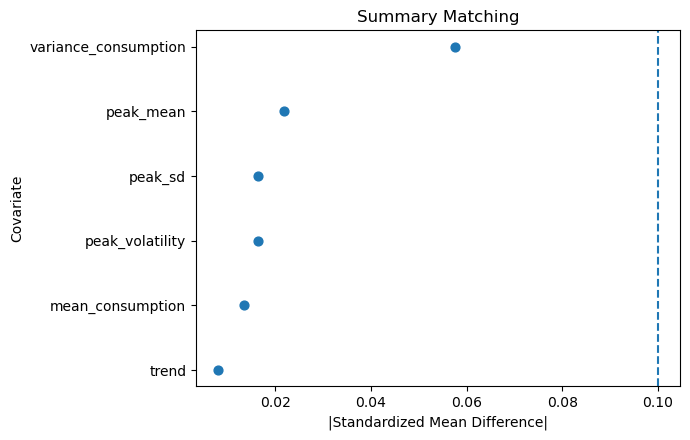

Rebuilding summary profiles for validation...
Matched profiles count = 9718

=== MATCHING VARIABLES ===
+--------------------+-------------------+-------------------+---------------------+
|covariate           |treated_mean       |control_mean       |SMD                  |
+--------------------+-------------------+-------------------+---------------------+
|peak_mean           |6.3093479367395755 |6.240096043534006  |0.021893087460565997 |
|peak_sd             |1.408372294048179  |1.3924838960565593 |0.016423551786183637 |
|peak_volatility     |0.9089504211513721 |0.8995592292598765 |0.016346505436642338 |
|mean_consumption    |1.337627547559283  |1.3465933112680366 |-0.013395919435631861|
|variance_consumption|1.6668940160750698 |1.5744779380493996 |0.05754943463505725  |
|trend               |0.09942157383354666|0.09724757888222879|0.008056180076686226 |
+--------------------+-------------------+-------------------+---------------------+


--------------------------------------------

In [ ]:
print("Running summary matching 4...")

# ============================================================
# STEP 0: build risk_rows（🔥必要）
# ============================================================
risk_rows = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,
    control_type="never_treated",
    verbose=True
)

# ============================================================
# STEP 1: matching（🔥改成用 risk_rows）
# ============================================================
res_summary_4 = run_summary_matching_pipeline(
    output_folder="Files/output/matching/summary_4",
    risk_rows=risk_rows,   # 🔥關鍵修正
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "peak_volatility",
        "mean_consumption",
        "variance_consumption",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# ============================================================
# STEP 2: save（OK）
# ============================================================
save_matching_results_fabric(
    res=res_summary_4,
    folder="Files/output/matching/summary_4",
    config={
        "type": "summary",
        "vars": [
            "peak_mean",
            "peak_sd",
            "peak_volatility",
            "mean_consumption",
            "variance_consumption",
            "trend"
        ]
    },
)

# ============================================================
# STEP 3: love plot（OK）
# ============================================================
love_plot_from_spark(
    res_summary_4["balance"],
    output_path=None,
    title="Summary Matching 4"
)

# ============================================================
# STEP 4: validation（🔥一定要加 sdf）
# ============================================================
check_balance_full_safe(
    res=res_summary_4,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)